# Testbench for `radioml_top()`

In [1]:
#
# Copyright (C) 2024, Advanced Micro Devices, Inc. All rights reserved.
# SPDX-License-Identifier: MIT
#
# Author: Faisal El-Shabani

In [2]:
from tensorflow import keras
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import h5py as h5
import numpy as np
import os.path
import json
import vfs
import varray as va

NITERATIONS = 8    # Number of AI Engine graph iterations

2025-09-11 18:31:53.245190: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-11 18:31:53.249482: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-11 18:31:53.258766: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757637113.273665  445476 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757637113.277968  445476 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1757637113.291130  445476 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Layer Definition

In [3]:
inputs = keras.Input(shape=(1024,2),name="input")
x1 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w1",activation='relu')(inputs)
x2 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w2")(x1)
x3 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w3",activation='relu')(x2)
x4 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w4")(x3)
x5 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w5",activation='relu')(x4)
x6 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w6")(x5)
x7 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w7",activation='relu')(x6)
x8 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w8")(x7)
x9 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w9",activation='relu')(x8)
x10 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w10")(x9)
x11 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w11",activation='relu')(x10)
x12 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w12")(x11)
x13 = Conv1D(filters=64,kernel_size=7,strides=1,padding="same",name="conv1D_w13",activation='relu')(x12)
x14 = MaxPooling1D(pool_size=2,strides=2,padding="valid",name="max_pool1d_w14")(x13)
x15 = Flatten(name="flatten_w15")(x14)
x16 = Dense(128, activation="selu",name="dense_w16")(x15)
x17 = Dense(128, activation="selu",name="dense_w17")(x16)
outputs = Dense(24, activation="softmax",name="dense_w18")(x17)

model_stim = keras.Model(inputs=inputs,outputs=outputs)
model_stim.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
w1_weights = np.loadtxt('../conv1d_w1/w1_weights_trained.txt')
w1_weights = (w1_weights.astype("bfloat16")).astype("float32")
w1_weights = np.reshape(w1_weights,(7,2,64))
w1_bias = np.loadtxt('../conv1d_w1/w1_bias_trained.txt')
w1_bias = (w1_bias.astype("bfloat16")).astype("float32")

w3_weights = np.loadtxt('../conv1d_template/w3_weights_trained.txt')
w3_weights = (w3_weights.astype("bfloat16")).astype("float32")
w3_weights = np.reshape(w3_weights,(7,64,64))
w3_bias = np.loadtxt('../conv1d_template/w3_bias_trained.txt')
w3_bias = (w3_bias.astype("bfloat16")).astype("float32")

w5_weights = np.loadtxt('../conv1d_template/w5_weights_trained.txt')
w5_weights = (w5_weights.astype("bfloat16")).astype("float32")
w5_weights = np.reshape(w5_weights,(7,64,64))
w5_bias = np.loadtxt('../conv1d_template/w5_bias_trained.txt')
w5_bias = (w5_bias.astype("bfloat16")).astype("float32")

w7_weights = np.loadtxt('../conv1d_template/w7_weights_trained.txt')
w7_weights = (w7_weights.astype("bfloat16")).astype("float32")
w7_weights = np.reshape(w7_weights,(7,64,64))
w7_bias = np.loadtxt('../conv1d_template/w7_bias_trained.txt')
w7_bias = (w7_bias.astype("bfloat16")).astype("float32")

w9_weights = np.loadtxt('../conv1d_template/w9_weights_trained.txt')
w9_weights = (w9_weights.astype("bfloat16")).astype("float32")
w9_weights = np.reshape(w9_weights,(7,64,64))
w9_bias = np.loadtxt('../conv1d_template/w9_bias_trained.txt')
w9_bias = (w9_bias.astype("bfloat16")).astype("float32")

w11_weights = np.loadtxt('../conv1d_template/w11_weights_trained.txt')
w11_weights = (w11_weights.astype("bfloat16")).astype("float32")
w11_weights = np.reshape(w11_weights,(7,64,64))
w11_bias = np.loadtxt('../conv1d_template/w11_bias_trained.txt')
w11_bias = (w11_bias.astype("bfloat16")).astype("float32")

w13_weights = np.loadtxt('../conv1d_template/w13_weights_trained.txt')
w13_weights = (w13_weights.astype("bfloat16")).astype("float32")
w13_weights = np.reshape(w13_weights,(7,64,64))
w13_bias = np.loadtxt('../conv1d_template/w13_bias_trained.txt')
w13_bias = (w13_bias.astype("bfloat16")).astype("float32")

w16_weights = np.loadtxt('../dense_w16/w16_weights_trained.txt')
w16_weights = (w16_weights.astype("bfloat16")).astype("float32")
w16_weights = np.reshape(w16_weights,(512,128))
w16_bias = np.loadtxt('../dense_w16/w16_bias_trained.txt')
w16_bias = (w16_bias.astype("bfloat16")).astype("float32")

w17_weights = np.loadtxt('../dense_w17/w17_weights_trained.txt')
w17_weights = (w17_weights.astype("bfloat16")).astype("float32")
w17_weights = np.reshape(w17_weights,(128,128))
w17_bias = np.loadtxt('../dense_w17/w17_bias_trained.txt')
w17_bias = (w17_bias.astype("bfloat16")).astype("float32")

w18_weights = np.loadtxt('../dense_w18/w18_weights_trained.txt')
w18_weights = (w18_weights.astype("bfloat16")).astype("float32")
w18_weights = np.reshape(w18_weights,(128,24))
w18_bias = np.loadtxt('../dense_w18/w18_bias_trained.txt')
w18_bias = (w18_bias.astype("bfloat16")).astype("float32")

model_stim.get_layer("conv1D_w1").set_weights((w1_weights,w1_bias))
model_stim.get_layer("conv1D_w3").set_weights((w3_weights,w3_bias))
model_stim.get_layer("conv1D_w5").set_weights((w5_weights,w5_bias))
model_stim.get_layer("conv1D_w7").set_weights((w7_weights,w7_bias))
model_stim.get_layer("conv1D_w9").set_weights((w9_weights,w9_bias))
model_stim.get_layer("conv1D_w11").set_weights((w11_weights,w11_bias))
model_stim.get_layer("conv1D_w13").set_weights((w13_weights,w13_bias))
model_stim.get_layer("dense_w16").set_weights((w16_weights,w16_bias))
model_stim.get_layer("dense_w17").set_weights((w17_weights,w17_bias))
model_stim.get_layer("dense_w18").set_weights((w18_weights,w18_bias))


2025-09-11 18:31:58.168410: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
model_stim.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1024, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w1 (Conv1D)              │ (None, 1024, 64)       │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w2 (MaxPooling1D)    │ (None, 512, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w3 (Conv1D)              │ (None, 512, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w4 (MaxPooling1D)    │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w5 (Conv1D)              │ (None, 256, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w6 (MaxPooling1D)    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w7 (Conv1D)              │ (None, 128, 64)        │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w8 (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w9 (Conv1D)              │ (None, 64, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w10 (MaxPooling1D)   │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w11 (Conv1D)             │ (None, 32, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w12 (MaxPooling1D)   │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1D_w13 (Conv1D)             │ (None, 16, 64)         │        28,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool1d_w14 (MaxPooling1D)   │ (None, 8, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_w15 (Flatten)           │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_w16 (Dense)               │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_w17 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_w18 (Dense)               │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,648 (1010.34 KB)

 Trainable params: 258,648 (1010.34 KB)

 Non-trainable params: 0 (0.00 B)

### Read training and test data

In [5]:
if not("RADIOML_DATA" in os.environ):
    print("Please set environment variable RADIOML_DATA to point to dataset found in https://www.kaggle.com/datasets/pinxau1000/radioml2018")
data_file = os.environ["RADIOML_DATA"] + 'GOLD_XYZ_OSC.0001_1024.hdf5'
file_handle = h5.File(data_file,'r')
myData = file_handle['X'][:]  #1024x2 samples 
myMods = file_handle['Y'][:]  #mods 
mySNRs = file_handle['Z'][:]  #snrs  
file_handle.close()
modulation_classes = json.load(open(os.environ["RADIOML_DATA"] + "classes-fixed.json", 'r'))
myDataReshaped = myData.reshape(24,26,4096,1024,2) #(modulation,SNR,frame,I,Q)
myModsReshaped = myMods.reshape(24,26,4096,24) #(modulation,SNR,frame,modulation_onehot)
X_predict = myDataReshaped[:NITERATIONS,25,0,:,:]
X_predict = (X_predict.astype("bfloat16")).astype("float32")


## Compute Golden Outputs

In [6]:
predict = model_stim.predict(X_predict,batch_size=1024)
predict = (predict.astype("bfloat16")).astype("float32")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step


## Store Layer Inputs

In [7]:
# Create directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')
data_iq = np.reshape(X_predict,(-1,1))
np.savetxt('data/data_iq.txt',np.reshape(data_iq,(-1,4)),fmt='%.12f %.12f %.12f %.12f')


## Store Layer Outputs

In [8]:
data_o = np.vstack(predict)

np.savetxt('data/data_o.txt',np.reshape(data_o,(-1,4)),fmt='%.12f %.12f %.12f %.12f')
print(data_o.shape)


(8, 24)


## Store Model weights and biases

In [9]:
w1_weights = np.reshape(w1_weights,(-1,1))
w1_bias = np.reshape(w1_bias,(-1,1))
np.savetxt('data/w1_weights-rtp.txt',w1_weights,fmt='%.12f')
np.savetxt('data/w1_biases-rtp.txt',w1_bias,fmt='%.12f')

weights = np.empty((7*64*64),dtype='bfloat16')
counter=0
for x in range(0,64,8):
    for y in range(0,64,8):
        for z in range(0,7):
            weights[counter*64:(counter+1)*64] = np.reshape(w3_weights[z,y:y+8,x:x+8],(-1))
            counter+=1
w3_weights = np.reshape(weights,(-1,1))
np.savetxt('data/w3_weights-rtp.txt',w3_weights,fmt='%.12f')
w3_bias = np.vstack([np.reshape(w3_bias,(-1,1))])
np.savetxt('data/w3_biases-rtp.txt',w3_bias,fmt='%.12f')

weights = np.empty((7*64*64),dtype='bfloat16')
counter=0
for x in range(0,64,8):
    for y in range(0,64,8):
        for z in range(0,7):
            weights[counter*64:(counter+1)*64] = np.reshape(w5_weights[z,y:y+8,x:x+8],(-1))
            counter+=1
w5_weights = np.reshape(weights,(-1,1))
np.savetxt('data/w5_weights-rtp.txt',w5_weights,fmt='%.12f')
w5_bias = np.vstack([np.reshape(w5_bias,(-1,1))])
np.savetxt('data/w5_biases-rtp.txt',w5_bias,fmt='%.12f')

weights = np.empty((7*64*64),dtype='bfloat16')
counter=0
for x in range(0,64,8):
    for y in range(0,64,8):
        for z in range(0,7):
            weights[counter*64:(counter+1)*64] = np.reshape(w7_weights[z,y:y+8,x:x+8],(-1))
            counter+=1
w7_weights = np.reshape(weights,(-1,1))
np.savetxt('data/w7_weights-rtp.txt',w7_weights,fmt='%.12f')
w7_bias = np.vstack([np.reshape(w7_bias,(-1,1))])
np.savetxt('data/w7_biases-rtp.txt',w7_bias,fmt='%.12f')

weights = np.empty((7*64*64),dtype='bfloat16')
counter=0
for x in range(0,64,8):
    for y in range(0,64,8):
        for z in range(0,7):
            weights[counter*64:(counter+1)*64] = np.reshape(w9_weights[z,y:y+8,x:x+8],(-1))
            counter+=1
w9_weights = np.reshape(weights,(-1,1))
np.savetxt('data/w9_weights-rtp.txt',w9_weights,fmt='%.12f')
w9_bias = np.vstack([np.reshape(w9_bias,(-1,1))])
np.savetxt('data/w9_biases-rtp.txt',w9_bias,fmt='%.12f')

weights = np.empty((7*64*64),dtype='bfloat16')
counter=0
for x in range(0,64,8):
    for y in range(0,64,8):
        for z in range(0,7):
            weights[counter*64:(counter+1)*64] = np.reshape(w11_weights[z,y:y+8,x:x+8],(-1))
            counter+=1
w11_weights = np.reshape(weights,(-1,1))
np.savetxt('data/w11_weights-rtp.txt',w11_weights,fmt='%.12f')
w11_bias = np.vstack([np.reshape(w11_bias,(-1,1))])
np.savetxt('data/w11_biases-rtp.txt',w11_bias,fmt='%.12f')

weights = np.empty((7*64*64),dtype='bfloat16')
counter=0
for x in range(0,64,8):
    for y in range(0,64,8):
        for z in range(0,7):
            weights[counter*64:(counter+1)*64] = np.reshape(w13_weights[z,y:y+8,x:x+8],(-1))
            counter+=1
w13_weights = np.reshape(weights,(-1,1))
np.savetxt('data/w13_weights-rtp.txt',w13_weights,fmt='%.12f')
w13_bias = np.vstack([np.reshape(w13_bias,(-1,1))])
np.savetxt('data/w13_biases-rtp.txt',w13_bias,fmt='%.12f')

# dense_w16: Munge weights to make compute more efficient
tmp = np.transpose(w16_weights[:,:64])
w16_0_weights = np.array([],dtype='bfloat16')
for i in range(tmp.shape[1]):
    w16_0_weights = np.concat((w16_0_weights,np.diag(np.roll(tmp,-i,axis=1))))
np.savetxt('data/w16_0_weights-rtp.txt',w16_0_weights,fmt='%.12f')
tmp = np.transpose(w16_weights[:,64:])
w16_1_weights = np.array([],dtype='bfloat16')
for i in range(tmp.shape[1]):
    w16_1_weights = np.concat((w16_1_weights,np.diag(np.roll(tmp,-i,axis=1))))
np.savetxt('data/w16_1_weights-rtp.txt',w16_1_weights,fmt='%.12f')
w16_bias = np.reshape(w16_bias,(-1,1))
np.savetxt('data/w16_biases-rtp.txt',w16_bias,fmt='%.12f')

# dense_w17: Munge weights to make compute more efficient
tmp1 = np.transpose(w17_weights[:,:64])
tmp2 = np.transpose(w17_weights[:,64:])
weights = np.array([],dtype='bfloat16')
for i in range(tmp1.shape[1]):
    weights = np.concat((weights,np.diag(np.roll(tmp1,-i,axis=1))))
    weights = np.concat((weights,np.diag(np.roll(tmp2,-i,axis=1))))
w17_weights = weights
np.savetxt('data/w17_weights-rtp.txt',w17_weights,fmt='%.12f')
w17_bias = np.reshape(w17_bias,(-1,1))
np.savetxt('data/w17_biases-rtp.txt',w17_bias,fmt='%.12f')

# dense_w18: 
w18_weights = np.reshape(np.transpose(w18_weights),(-1,1))
np.savetxt('data/w18_weights-rtp.txt',w18_weights,fmt='%.12f')
w18_bias = np.reshape(w18_bias,(-1,1))
np.savetxt('data/w18_biases-rtp.txt',w18_bias,fmt='%.12f')


### Store modulation_classes for host program

In [10]:
print(modulation_classes)
np.savetxt('data/modulation_classes.txt',modulation_classes,fmt='%s')


['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


## Run Vitis Functional Simulation

In [11]:
radioml_top_graph = vfs.aieGraph(
    input_file='radioml_top_app.cpp',
    part="xc2ve3858-ssva2112-2MP-e-S",
    include_paths=['./','../conv1d_w1','../max_pool1d_w2','../conv1d_template','../max_pool1d_template','../dense_w16','../dense_w17','../dense_w18','../utility'])
act_o = radioml_top_graph.run(va.array(data_iq,dtype=va.bfloat16),
                              va.array(w1_weights,dtype=va.bfloat16),va.array(w1_bias,dtype=va.bfloat16),
                              va.array(w3_weights,dtype=va.bfloat16),va.array(w3_bias,dtype=va.bfloat16),
                              va.array(w5_weights,dtype=va.bfloat16),va.array(w5_bias,dtype=va.bfloat16),
                              va.array(w7_weights,dtype=va.bfloat16),va.array(w7_bias,dtype=va.bfloat16),
                              va.array(w9_weights,dtype=va.bfloat16),va.array(w9_bias,dtype=va.bfloat16),
                              va.array(w11_weights,dtype=va.bfloat16),va.array(w11_bias,dtype=va.bfloat16),
                              va.array(w13_weights,dtype=va.bfloat16),va.array(w13_bias,dtype=va.bfloat16),
                              va.array(w16_0_weights,dtype=va.bfloat16),va.array(w16_1_weights,dtype=va.bfloat16),va.array(w16_bias,dtype=va.bfloat16),
                              va.array(w17_weights,dtype=va.bfloat16),va.array(w17_bias,dtype=va.bfloat16),
                              va.array(w18_weights,dtype=va.bfloat16),va.array(w18_bias,dtype=va.bfloat16)
                              )
act_o = np.array(act_o,dtype='bfloat16')



Compiling AIE Graph
Compilation directory: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/radioml_top
Compilation command: v++ -c --mode aie --config vfs_work/radioml_top_app_06d6bfe7/radioml_top_app.cfg --work_dir vfs_work/radioml_top_app_06d6bfe7/Work --output vfs_work/radioml_top_app_06d6bfe7/libadf.a --target x86sim
Writing log to: /group/fndprod/faisale/repo/internal/designs/radio-ml/aie/radioml_top/vfs_work/radioml_top_app_06d6bfe7/Work/logs/aie_x86sim.log
Please wait ...

Compilation finished successfully.


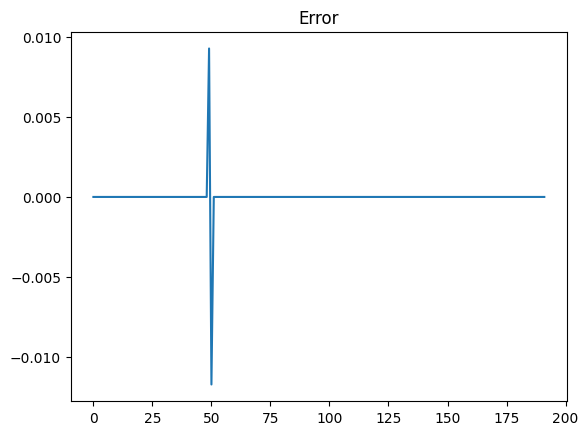

In [12]:
data_o_reshaped = np.reshape(data_o,(-1))
err = data_o_reshaped-act_o
plt.plot(err)
plt.title("Error")
plt.show()
